In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

To run a set of benchmarks we'll want to run:
```
cd ~/sophgo/smokewagon-benchmarks
gcc microbenchmark-mmap.c
./a.out -t 64
./a.out -t 64 -s
./a.out -t 64 -f
./a.out -t 64 -s -f
```

In [193]:
import subprocess

result = subprocess.run([
    "scp milkv@192.168.50.195:~/sophgo/smokewagon-benchmarks/result-* ~/sophgo/smokewagon-benchmarks/"],
    capture_output=True, text=True, shell=True, check=True)
print(result.stdout)

In [194]:
from pathlib import Path

hash_names = {
    "7e04b46c5be60068f5002ca9bc647bff737f0542" : "xarray-fixed",
    "e996d506d9c8f534dd32edcf5139ba3aaee48b19" : "add-fork",
    "24ac9404254c0ee7cccd53821e73af8c81fb9a46" : "xarray-bug",
    "c277100ed866fc7f3cfae0b6172c5d3ed2ab5bb0" : "flat1GB",
    "eadff10a39c6faf2e486ed108e3a3bc4c2bb77b3" : "baseline",
}

import pandas as pd
import matplotlib.pyplot as plt

prefix = "result-microbenchmark-mmap-"
suffix = ".csv"
result_files = Path("~/sophgo/smokewagon-benchmarks").expanduser().glob(prefix + "*" + suffix)
dfs = []

for f in result_files:
    df = pd.read_csv(f, index_col=0)

    # column name faff
    label = f.name[len(prefix):-len(suffix)].split("-")
    col_label = tuple([label[1], label[0], hash_names.get(label[2])])
    df.columns = pd.MultiIndex.from_tuples([col_label])

    dfs.append(df)

df = pd.concat(dfs, axis=1)
# sorting columns now helps keep consistency in plotting later
df = df.reindex(sorted(df.columns), axis=1)
df.to_csv('smokewagon-microbenchmark-results.csv')
df

filebacked                                                        \
          inactive                                 smokewagon              
          baseline flat1GB xarray-bug xarray-fixed    flat1GB xarray-bug   
threads                                                                    
1           158711  149434     149309       134160      57582      54959   
2            96751   91016      90952        85327      96206      94813   
3            88716   82350      90410        80080      73066      68656   
4            82140   76667      89989        75598      72717      64402   
5            83135   76571      79273        75593      71843      64167   
...            ...     ...        ...          ...        ...        ...   
60           31588   31060      31057        30860      65344      65287   
61           31431   30769      30811        30709      65485      65009   
62           31113   30432      30497        30404      64774      65699   
63           30656   29909      30011        29893      65071      62382   
64           30158   29489      29586        29413      64931      64848   

                     membacked                                             \
                      inactive                                 smokewagon   
        xarray-fixed  baseline flat1GB xarray-bug xarray-fixed    flat1GB   
threads                                                                     
1             158312    106592   72613      73050        71988      35742   
2             188574     68593   62262      65956        64447      60087   
3             144843     60391   55177      58042        56661      50529   
4             155730     60595   52287      57823        58371      47416   
5             161902     56005   53163      54417        53521      45156   
...              ...       ...     ...        ...          ...        ...   
60            176700     25707   25377      25360        25385      42515   
61            175872     25622   25276      25193        25253      42524   
62            175997     25351   25007      24956        24990      42405   
63            176179     25070   24722      24660        24677      42357   
64            178214     24750   24390      24377        24402      42125   

                                 
                                 
        xarray-bug xarray-fixed  
threads                          
1            35043        78045  
2            59232       137445  
3            49476       142484  
4            46630       115629  
5            49249       108689  
...            ...          ...  
60           40516        97225  
61           40674        96222  
62           40793        95638  
63           40579        95773  
64           38440        95005  

[64 rows x 14 columns]

In [195]:
df.unstack().unstack()

threads                                 1       2       3       4       5   \
filebacked inactive   baseline      158711   96751   88716   82140   83135   
                      flat1GB       149434   91016   82350   76667   76571   
                      xarray-bug    149309   90952   90410   89989   79273   
                      xarray-fixed  134160   85327   80080   75598   75593   
           smokewagon flat1GB        57582   96206   73066   72717   71843   
                      xarray-bug     54959   94813   68656   64402   64167   
                      xarray-fixed  158312  188574  144843  155730  161902   
membacked  inactive   baseline      106592   68593   60391   60595   56005   
                      flat1GB        72613   62262   55177   52287   53163   
                      xarray-bug     73050   65956   58042   57823   54417   
                      xarray-fixed   71988   64447   56661   58371   53521   
           smokewagon flat1GB        35742   60087   50529   47416   45156   
                      xarray-bug     35043   59232   49476   46630   49249   
                      xarray-fixed   78045  137445  142484  115629  108689   

threads                                 6       7       8       9       10  \
filebacked inactive   baseline       80721   77390   74121   73762   71715   
                      flat1GB        75076   72823   70115   70854   69524   
                      xarray-bug     78753   75662   73478   71237   70121   
                      xarray-fixed   73835   71675   69520   68959   67206   
           smokewagon flat1GB        72222   72221   72962   72438   72171   
                      xarray-bug     66896   70537   70159   72686   72450   
                      xarray-fixed  163689  165986  165187  167097  167093   
membacked  inactive   baseline       54742   53066   51255   50013   49207   
                      flat1GB        51546   49870   48334   47705   46912   
                      xarray-bug     52959   51428   49868   48329   47599   
                      xarray-fixed   52434   50849   49181   48377   47325   
           smokewagon flat1GB        46656   51076   50589   50194   49317   
                      xarray-bug     47285   49781   48726   42038   45917   
                      xarray-fixed  108737  103735  105311  105920  104370   

threads                             ...      55      56      57      58  \
filebacked inactive   baseline      ...   33789   33251   33065   32659   
                      flat1GB       ...   32954   32510   32261   31903   
                      xarray-bug    ...   33105   32611   32355   31997   
                      xarray-fixed  ...   33029   32495   32214   31867   
           smokewagon flat1GB       ...   65729   65152   65260   65160   
                      xarray-bug    ...   66429   66127   65664   65902   
                      xarray-fixed  ...  176472  177796  178961  179412   
membacked  inactive   baseline      ...   27109   26739   26640   26362   
                      flat1GB       ...   26774   26447   26326   26056   
                      xarray-bug    ...   26717   26356   26256   25990   
                      xarray-fixed  ...   26760   26398   26265   26010   
           smokewagon flat1GB       ...   42150   42489   42777   42744   
                      xarray-bug    ...   40302   40072   39252   39681   
                      xarray-fixed  ...   98528   98230   96708   97384   

threads                                 59      60      61      62      63  \
filebacked inactive   baseline       32192   31588   31431   31113   30656   
                      flat1GB        31446   31060   30769   30432   29909   
                      xarray-bug     31543   31057   30811   30497   30011   
                      xarray-fixed   31179   30860   30709   30404   29893   
           smokewagon flat1GB        65549   65344   65485   64774   65071   
                      xarray-bug     65310   65287   65009   656

In [196]:
mask = (
    (df.columns.get_level_values(0) == "filebacked") &
    (
        (df.columns.get_level_values(1) == "smokewagon") |
        (
            (df.columns.get_level_values(1) == "inactive") &
            (df.columns.get_level_values(2) == "baseline")
        )
    )
)

subset = df.loc[:, mask]
subset

filebacked                                   
          inactive smokewagon                        
          baseline    flat1GB xarray-bug xarray-fixed
threads                                              
1           158711      57582      54959       158312
2            96751      96206      94813       188574
3            88716      73066      68656       144843
4            82140      72717      64402       155730
5            83135      71843      64167       161902
...            ...        ...        ...          ...
60           31588      65344      65287       176700
61           31431      65485      65009       175872
62           31113      64774      65699       175997
63           30656      65071      62382       176179
64           30158      64931      64848       178214

[64 rows x 4 columns]

In [197]:
cmap = plt.get_cmap("Dark2")
color_keys = df.columns.droplevel(0).unique()
colors = {key: cmap(i % 8) for i, key in enumerate(color_keys)}

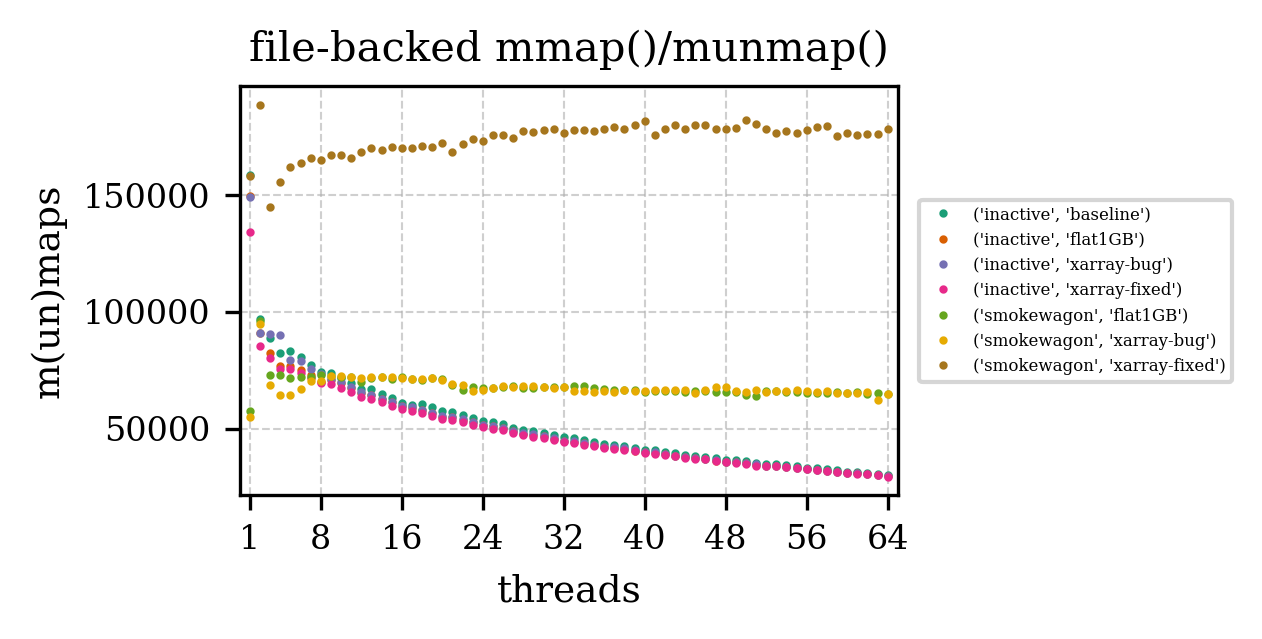

In [198]:
mask = df.columns.get_level_values(0) == "filebacked"
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("file-backed mmap()/munmap()")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
#plt.savefig("microbenchmark-mmap-filebacked.pdf", bbox_inches="tight")

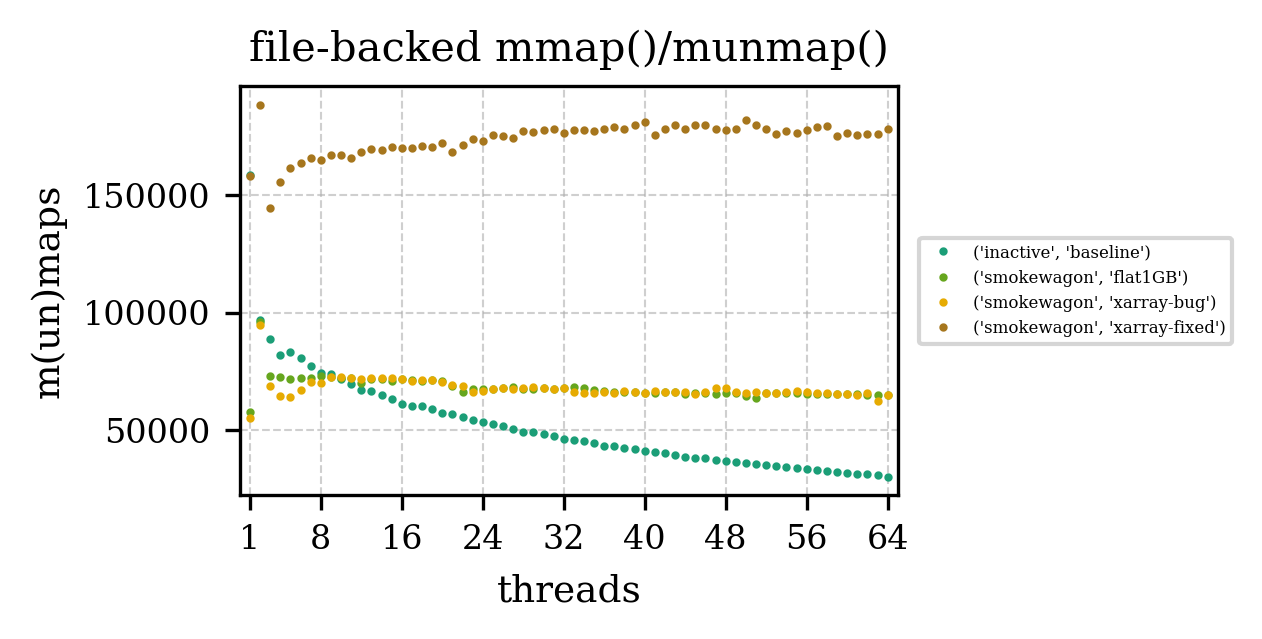

In [199]:
mask = (
    (df.columns.get_level_values(0) == "filebacked") &
    (
        (df.columns.get_level_values(1) == "smokewagon") |
        (
            (df.columns.get_level_values(1) == "inactive") &
            (df.columns.get_level_values(2) == "baseline")
        )
    )
)
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("file-backed mmap()/munmap()")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-filebacked.pdf", bbox_inches="tight")

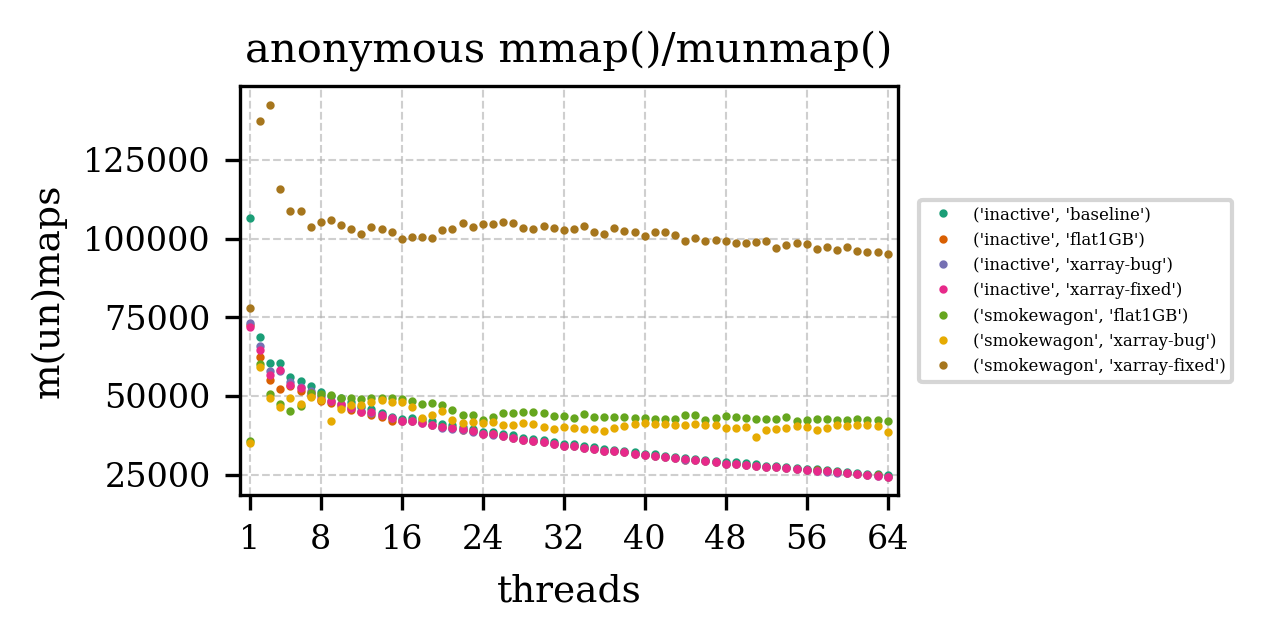

In [200]:
mask = df.columns.get_level_values(0) == "membacked"
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("anonymous mmap()/munmap()")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
#plt.savefig("microbenchmark-mmap-membacked.pdf", bbox_inches="tight")

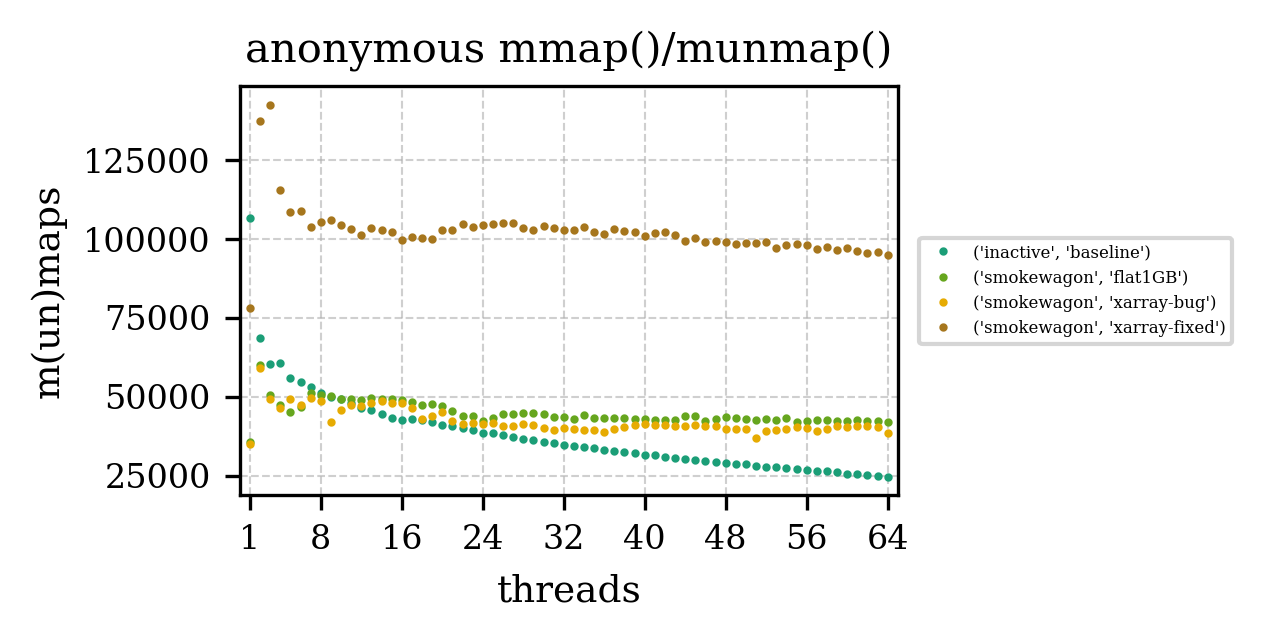

In [201]:
mask = (
    (df.columns.get_level_values(0) == "membacked") &
    (
        (df.columns.get_level_values(1) == "smokewagon") |
        (
            (df.columns.get_level_values(1) == "inactive") &
            (df.columns.get_level_values(2) == "baseline")
        )
    )
)
subset = df.loc[:, mask]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 7,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 300
})
fig, ax = plt.subplots(figsize=(4.3, 2.2))  # ACM single-column width is about (3.3, 2.2)
for col in subset.columns:
    ax.plot(
        subset.index,
        subset[col],
        '.',
        markersize=2,
        color=colors[col[1:]],
        label=str(col)
    )
ax.set_title("anonymous mmap()/munmap()")
ax.set_xlabel("threads")
ax.set_ylabel("m(un)maps")
ax.set_xlim(left=0, right=65)
ax.set_xticks([1, 8, 16, 24, 32, 40, 48, 56, 64])
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
ax.legend(subset.columns.droplevel([0]), loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=4)
plt.tight_layout()
plt.savefig("microbenchmark-mmap-membacked.pdf", bbox_inches="tight")